__Guangyun Yunjing Crossvisualization__
Step 0: Import libraries
Step 1: Load relevant .csv files
Step 2: Create & Validate dataframe for visualization. 
Step 3: Create Guangyun rime (韻目原貌) to Rime group (she 攝) dictionary
Step 4: Create crosstab: for each Guangyun rime (y-axis), how many homophone groups are in each division (x-axis)?
Step 5: Plot Heatmap & Touchup

In [56]:
#Step 0: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#set font for CJK
plt.rcParams['font.family'] = 'Heiti TC'

In [ ]:
#Step 1: Load relevant.csv files

Guangyun_csv = pd.read_csv("Raw Data/廣韻.csv")
Yunjing_csv = pd.read_csv("Raw Data/韻鏡（古逸叢書本）.csv") #This file only to check data with actual Yunjing

#print(Guangyun_csv.head())
#print(Yunjing_csv.head())

#Convert to Dataframe
Guangyun_raw = pd.DataFrame(Guangyun_csv)
Yunjing_raw = pd.DataFrame(Yunjing_csv)


  小韻號 小韻字號 韻目原貌  音韻地位  反切   直音 字頭 字頭說明  \
0   1    1    東  端一東平  德紅  NaN  東  NaN   
1   1    2    東  端一東平  德紅  NaN  菄  NaN   
2   1    3    東  端一東平  德紅  NaN  鶇  NaN   
3   1    4    東  端一東平  德紅  NaN  䍶  NaN   
4   1    5    東  端一東平  德紅  NaN  𠍀  NaN   

                                                  釋義 釋義參照  
0  春方也說文曰動也从日在木中亦東風菜廣州記云陸地生莖赤和肉作羹味如酪香似蘭吳都賦云莫則東風扶留...  NaN  
1                                         東風菜義見上注俗加艹    上  
2                                       鶇鵍鳥名美形出廣雅亦作𪂝  NaN  
3                    獸名山海經曰秦戲山有獸狀如羊一角一目目在耳後其名曰䍶又音陳音棟  NaN  
4                                           儱𠍀儜劣皃出字諟  NaN  
  字頭  轉號  上位  右位
0  蓬   1   1   3
1  蒙   1   1   4
2  東   1   1   5
3  通   1   1   6
4  同   1   1   7


In [ ]:
#Step 2: Create & Validate dataframe for visualization
#Extract from Guangyun_raw: Homophone group number (小韻號), Guangyun rime (韻目原貌), Rime Table Position (音韻地位) column
Guangyun_working = Guangyun_raw[['小韻號', '韻目原貌', '音韻地位']].copy()

print(Guangyun_working.head()) #validate first extract
#rename columns to English
Guangyun_working.columns = ['Homophone group number', 'Guangyun rime', 'Rime table position']

#Rime Table Position (RTP) is coded as: "initial type, （rounding）, division, （chongniu type）, rime class, tone", i.e., 母、（呼）、等、（類）、韻、聲。 
#Fields in () are optional.
#To parse this fixed pattern, use regex.
#Rime class (RC) = represented by the pingsheng (平聲) rime of a corresponding set of four rimes. (e.g. 東RC = 東/董/送/屋 rimes)
#CAUTION: Rime class are based on Qieyun (NOT Guangyun) rimes. See rime group_mapping.py for more on this.


import re
# ^ start of regex string
# initial type: (.) captures exactly one character.
# (rounding): [開合] capture 開 or 合 if present. ? optional marker
# division: [一二三四] captures 一 or 二 or 三or 四, if present
# (chongniu type): [ABC] captures A or B or C, if present. ? optional marker
# rime class: (.) captures exactly one character
# tone: [平上去入] captures 平 or 上 or 去 or 入, if present
# $ end of regex string
RTP_string = r'^(.)([開合]?)([一二三四])([ABC]?)(.)([平上去入])$'
#Validate that string works and that it is extracting
a = re.match(RTP_string, "端一東平")
print(a.groups())
b = re.match(RTP_string, "羣開三A支平")
print(b.groups())

#use str.extract() to extract capture groups in regex pattern as columns in a dataframe
RTP_extracted = Guangyun_working['Rime table position'].str.extract(RTP_string)
RTP_extracted.columns = ['initial type', 'rounding', 'division', 'chongniu type', 'rime class', 'tone']
#validate extraction
RTP_extracted.head()
#attach to Guangyun_working using df.join()
Guangyun_working = Guangyun_working.join(RTP_extracted)
#validate join
Guangyun_working.head()

#Data clean-up and catching edge cases/validation
#replace all empty strings to NaN using df.replace(). Requires numpy
import numpy as np
Guangyun_final = Guangyun_working.replace('', np.nan, inplace=True)

#Validate all rows parsed properly using .isna(). Only rounding and chongniu type should be non-zero, since these are optional values. 
#ALL other columns should be 0.
print(Guangyun_final.isna().sum())
#Validate count is correct
print(len(Guangyun_raw))
print(len(Guangyun_final))

#Preview Guangyun_final
print(Guangyun_final.head())
print(Guangyun_final.tail())

  小韻號 韻目原貌  音韻地位
0   1    東  端一東平
1   1    東  端一東平
2   1    東  端一東平
3   1    東  端一東平
4   1    東  端一東平
('端', '', '一', '', '東', '平')
('羣', '開', '三', 'A', '支', '平')
Homophone group number        0
Original rime                 0
Rime table position           0
initial type                  0
rounding                   7024
division                      0
chongniu type             19736
rime class                    0
tone                          0
dtype: int64
25336
25336
  Homophone group number Original rime Rime table position initial type  \
0                      1             東                端一東平            端   
1                      1             東                端一東平            端   
2                      1             東                端一東平            端   
3                      1             東                端一東平            端   
4                      1             東                端一東平            端   

  rounding division chongniu type rime class tone  
0      NaN        一   

In [ ]:
#Step 3: Create Guangyun rime (韻目原貌) to Rime group (she 攝) dictionary
#Created separate file rimeGroup_mapping.py containing dictionary rimeClass_to_rimeGroup necessary for plot.

#Add column for each character's rime group, based on their rime class
from rimeGroup_mapping import rimeClass_to_rimeGroup, rimeGroup_order
Guangyun_final['rime group'] = Guangyun_final['rime class'].map(rimeClass_to_rimeGroup)
print(Guangyun_final.head())

  Homophone group number Original rime Rime table position initial type  \
0                      1             東                端一東平            端   
1                      1             東                端一東平            端   
2                      1             東                端一東平            端   
3                      1             東                端一東平            端   
4                      1             東                端一東平            端   

  rounding division chongniu type rime class tone rime group  
0      NaN        一           NaN          東    平          通  
1      NaN        一           NaN          東    平          通  
2      NaN        一           NaN          東    平          通  
3      NaN        一           NaN          東    平          通  
4      NaN        一           NaN          東    平          通  


25336

In [58]:
#Step 4: Create crosstab: for each Guangun rime class (y-axis), how many homophone groups are in each division (x-axis)?
#Use Guangyun_final and rimeClass_to_rimeGroup dictionary

#Overarching question: what happens when the Guangyun's data is reorganized through the rime table's conceptual framework?
#Or, what happens when we move from a linear lookup mechanism (by tone->rime) to a two-dimensional lookup mechanism (initial and division in a rime group)?

#y-axis: Rime class (韻 in 音韻地位). This is essentially each individual table of the Yunjing. All characters in a table share the same final distinguished only by tone
#The rime classes are then re-ordered by rime group. This is a collection of tables where characters share vowel quality and coda.
#x-axis: Division. This is the main organizing principle that the Yunjing foregrounds.
#cell color: how many distinct homophone groups that that combination of (Division, Rime class). 
#GOAL: Heatmap. How the Guangyun's 58 rime classes distribute across the 4 divisions of the Yunjing, organized by rime group. This reveals which how densely populated each
#phonological slot is, or if they are structurally impossible. 

#Since we are only counting unique homophones (each unique sound), keep only one character from each unique homophone group. Use .drop_duplicates()
Guangyun_uniqueHomophones = Guangyun_final.drop_duplicates(subset='Homophone group number', ignore_index=True)
#Validate unique homophones only
#print(Guangyun_uniqueHomophones)
#print(len(Guangyun_uniqueHomophones))
#print(len(Yunjing_csv)) #There is interestingly less entries in the Yunjing itself. For future work.
#pd.crosstab(values to group by in rows, values to group by in columns)
ct = pd.crosstab(Guangyun_uniqueHomophones['rime class'], Guangyun_uniqueHomophones['division'])
#print(ct)
#print(ct.index) #rime classes are assigned randomly by pd.crosstab()
#sort rime classes based on canonical order of rime groups.
dict_key_order = list(rimeClass_to_rimeGroup.keys()) #get list of keys from rimeClass_to_rimeGroup in the order entered (insertion order)
sort_keys = {}
for rimeClass in ct.index:
    rimeGroup = rimeClass_to_rimeGroup[rimeClass] #lookup which rimeGroup the input rimeClass belongs to
    group_position = rimeGroup_order.index(rimeGroup) #determine where in rimeGroup list
    dict_position = dict_key_order.index(rimeClass) #second key, determine where in insertion order
    sort_keys[rimeClass] = (group_position, dict_position) #assign each rimeClass based on order of appearance of its corresponding rimeGroup, and then order of appearance within each rimeGroup as inserted

sort_series = pd.Series(sort_keys) #convert dictionary to one-dimensional array for sorting
ct = ct.loc[sort_series.sort_values().index] #sort_series.sort_values().index returns rime class names ordered by assigned position numbers. ct.loc() reorders the crosstab itself.
ct = ct[['一', '二', '三', '四']] #force the x-axis divisions to appear as 1234 (一二三四), since ct was displaying 1324 (一三二四).
print(ct)

division    一   二    三   四
東          62   0   59   0
冬          32   0    0   0
鍾           0   0   83   0
江           0  53    0   0
支           0   0  155   0
脂           0   0  132   1
之           0   0   74   0
微           0   0   44   0
魚           0   0   77   0
虞           0   0   78   0
模          56   0    0   0
齊           0   0    0  64
祭           0   0   38   0
泰          31   0    0   0
佳           0  50    0   0
皆           0  46    0   0
夬           0  19    0   0
灰          61   0    0   0
咍          45   0    0   0
廢           0   0   13   0
真           0   0  160   0
臻           0   0   13   0
文           0   0   37   0
殷           0   0   21   0
魂          73   0    0   0
痕          13   0    0   0
元           0   0   62   0
寒         126   0    0   0
刪           0  67    0   0
山           0  60    0   0
先           0   0    0  86
仙           0   0  190   0
蕭           0   0    0  33
宵           0   0   75   0
肴           0  51    0   0
豪          54   0    0   0
歌

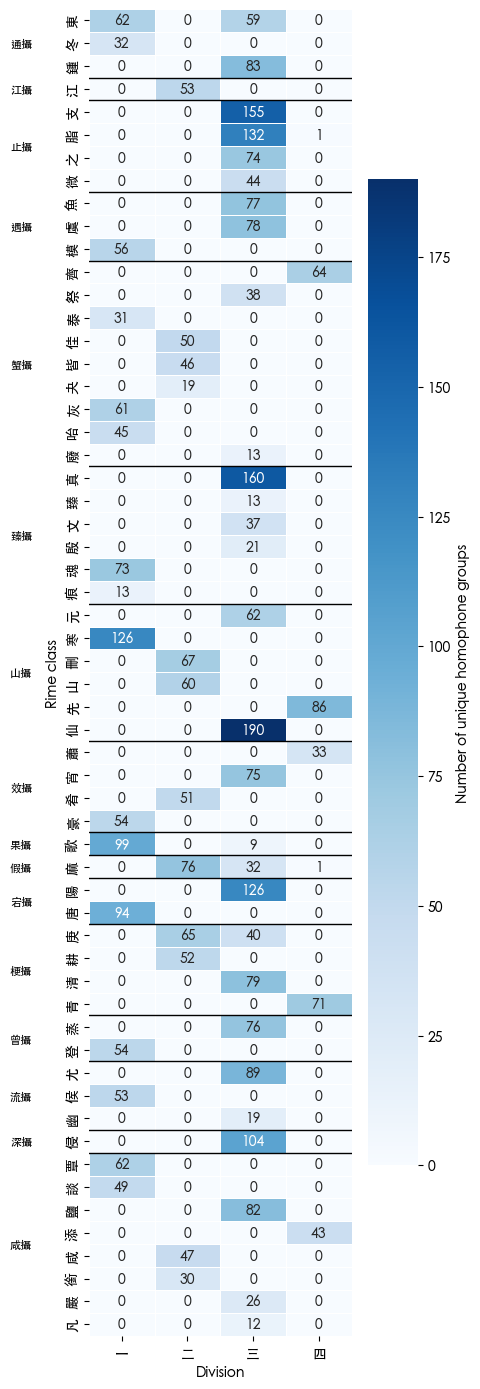

In [55]:
#Step 5: Plot Heatmap
#Set fixed figure size
fix, ax = plt.subplots(figsize=(5,14)) #can mess around with length and height)

#Draw heatmap baseplot
Yunjing_Crossvisualization = sns.heatmap(
    data=ct, #crosstab
    cmap='Blues', #color scheme
    annot=True, #no individual values in each cell
    fmt='d', #forces output to whole integers, if not numbers will appear funky
    cbar_kws={'label': 'Number of unique homophone groups'}, #label for color bar legend
    linewidths=0.5, #separate each cell since 58 rows
    ax=ax
)

#Set base axis labels
ax.set_xlabel("Division")
ax.set_ylabel("Rime class")

#Attempt to draw lines separating rime groups 攝
#Find out where each rime group starts and ends on y-axis
boundaries = []
group_labels = []
current_group = None
group_start = 0

for i, rimeClass in enumerate(ct.index):
    group = rimeClass_to_rimeGroup[rimeClass]
    if group != current_group:
        if current_group is not None:
            boundaries.append(i)
            midpoint = (group_start + i) / 2
            group_labels.append((midpoint, current_group))
        current_group = group
        group_start = i
midpoint = (group_start + len(ct)) / 2
group_labels.append((midpoint, current_group)) #Need to account for last group
#Draw horizontal lines between rime groups based on positions
for b in boundaries:
    ax.axhline(y=b, color='black', linewidth=1) #for each position, draw a horizontal line

# Place rime group labels as text just to the right of the heatmap
for pos, label in group_labels:
    ax.text(
        x=-1.2,  # on the left side of plot since negative
        y=pos,
        s=label + '攝',
        va='center',       # vertically center on the midpoint
        ha='left',          # align text to the left
        fontsize=8
    )

plt.tight_layout()
plt.show()

In [ ]:
#Export!
#plt.savefig('Guangyun-Yunjing-Crossvisualization.png', dpi=300, bbox_inches='tight')